# 08 · Survival Analysis — Boys Home Length of Stay & Slot Availability Forecast

## Problem Statement

When a young person is placed at a **Boys Home** (residential group home), they occupy one slot for the duration of their stay. Accurately predicting **how many slots will become available** over the coming weeks and months is essential for:

| Planning need | How this model helps |
|---|---|
| Accepting new referrals | Know today how many vacancies to expect next month |
| Budget / staffing | Align headcount to projected occupancy |
| Commissioning | Signal when new provision is needed |
| Matching with demand | Combine with the OOH demand forecast (notebooks 01–07) |

## Approach — Survival Analysis

Each placement is a **time-to-event** record:
* **Duration** — days from admission to discharge (or data cut-off if still active)
* **Event** — 1 = discharged, 0 = still placed (right-censored)

Classical regression cannot handle censored observations; **survival analysis** was designed exactly for this. We build three complementary models:

| Model | What it provides |
|---|---|
| **Kaplan–Meier** | Non-parametric survival curve — no assumptions needed |
| **Cox Proportional Hazards** | Identifies which client/referral features accelerate or delay discharge |
| **Weibull AFT** | Parametric curve — essential for smooth extrapolation beyond observed data |

## Connecting to the OOH Demand Pipeline

Notebooks 01–07 forecast **demand** (how many new placements will be requested).  
This notebook forecasts **supply** (how many slots will be available from existing placements).

```
Demand forecast (notebooks 01–07)  ──► New admissions expected
                                            │
Survival model (this notebook)     ──► Discharge timeline of current residents
                                            │
                                            ▼
                         Net available slots per facility × week
```


In [1]:
import subprocess, sys
try:
    import lifelines
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lifelines'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
from datetime import timedelta

from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
print(f'lifelines {lifelines.__version__} ready')


lifelines 0.30.3 ready


## 1 · Synthetic Placement Data

We simulate a realistic historical register of placements across five Boys Home facilities (January 2019 – March 2024). Each record represents one placement episode:

| Field | Description |
|---|---|
| `home_name` | Facility name |
| `capacity` | Total beds |
| `referral_type` | Emergency / Planned / Court Order / Step-Down |
| `age` | Age at admission (10–17) |
| `age_group` | 10–13 vs 14–17 |
| `prior_placements` | Number of prior placements |
| `admission_date` | Date placed |
| `duration_days` | Observed days (to discharge or data cut-off) |
| `event` | 1 = discharged; 0 = still active (right-censored) |

**Admission rate** is calibrated with Little's Law so steady-state utilisation ≈ 75%:

> `monthly_rate = capacity * 0.75 / (mean_LOS_months)`

**Length of stay** follows a log-normal distribution — a good empirical fit for residential care durations (heavy right tail: most leave within months, a minority stay years).


In [2]:
# ─── Simulation parameters ────────────────────────────────────────────────────
SIMULATION_START = pd.Timestamp("2019-01-01")
TODAY            = pd.Timestamp("2024-03-31")   # data cut-off
FORECAST_END     = TODAY + pd.DateOffset(months=6)

HOMES = {
    "Northgate House": {"capacity":  8, "mean_los": 180},
    "Riverdale Lodge":  {"capacity":  6, "mean_los": 240},
    "Westfield Manor":  {"capacity": 10, "mean_los": 150},
    "Elmwood Cottage":  {"capacity":  8, "mean_los": 200},
    "Parkview Centre":  {"capacity": 12, "mean_los": 160},
}
TOTAL_CAPACITY = sum(c["capacity"] for c in HOMES.values())

REFERRAL_TYPES = ["Emergency", "Planned", "Court Order", "Step-Down"]
REFERRAL_PROBS = [0.25, 0.40, 0.20, 0.15]
HAZARD_RATIOS  = {          # relative discharge rate vs Planned baseline
    "Emergency":   1.40,    # shorter stays — crisis resolved quickly
    "Planned":     1.00,    # baseline
    "Court Order": 0.65,    # longer stays — statutory requirement
    "Step-Down":   1.20,    # transitional, moderate length
}

# ─── Generate placement episodes ──────────────────────────────────────────────
np.random.seed(SEED)
rows = []
n_months = (TODAY.year - SIMULATION_START.year)*12 + (TODAY.month - SIMULATION_START.month)

for home_name, cfg in HOMES.items():
    # Little's Law: target 75% utilisation at steady state
    monthly_rate = cfg["capacity"] * 0.75 / (cfg["mean_los"] / 30)
    for m in range(n_months):
        month_start = SIMULATION_START + pd.DateOffset(months=m)
        n_admits = np.random.poisson(monthly_rate)
        for _ in range(n_admits):
            admission_date = month_start + timedelta(days=np.random.randint(0, 28))
            if admission_date >= TODAY:
                continue
            referral = np.random.choice(REFERRAL_TYPES, p=REFERRAL_PROBS)
            age      = np.random.randint(10, 18)
            prior    = np.random.choice([0, 1, 2, 3], p=[0.45, 0.30, 0.15, 0.10])
            mean_los_adj = cfg["mean_los"] / HAZARD_RATIOS[referral]
            sigma_log    = 0.65
            mu_log       = np.log(mean_los_adj) - sigma_log**2 / 2
            los_days     = max(7, int(np.random.lognormal(mu_log, sigma_log)))
            discharge_date = admission_date + timedelta(days=los_days)
            if discharge_date >= TODAY:
                duration, event = (TODAY - admission_date).days, 0
            else:
                duration, event = los_days, 1
            rows.append({
                "home_name": home_name, "capacity": cfg["capacity"],
                "referral_type": referral, "age": age,
                "age_group": "10-13" if age <= 13 else "14-17",
                "prior_placements": prior, "admission_date": admission_date,
                "duration_days": duration, "event": event,
            })

df = pd.DataFrame(rows)
active_df = df[df["event"] == 0].copy()
active_df["current_duration"] = (TODAY - active_df["admission_date"]).dt.days

print(f"Historical records : {len(df):>5,}")
print(f"  Discharged (1)   : {df['event'].sum():>5,}  ({df['event'].mean():.1%})")
print(f"  Active now   (0) : {(1-df['event']).sum():>5,}  ({(1-df['event']).mean():.1%})")
print()
print(f"{'Home':<20} {'Active':>6} {'Capacity':>8} {'Utilisation':>12}")
print("-" * 50)
for home, cfg in HOMES.items():
    n_act = len(active_df[active_df["home_name"] == home])
    print(f"{home:<20} {n_act:>6} {cfg['capacity']:>8} {n_act/cfg['capacity']:>11.0%}")
print("-" * 50)
print(f"{'TOTAL':<20} {len(active_df):>6} {TOTAL_CAPACITY:>8} {len(active_df)/TOTAL_CAPACITY:>11.0%}")


Historical records :   321
  Discharged (1)   :   294  (91.6%)
  Active now   (0) :    27  (8.4%)

Home                 Active Capacity  Utilisation
--------------------------------------------------
Northgate House           1        8         12%
Riverdale Lodge           3        6         50%
Westfield Manor           8       10         80%
Elmwood Cottage           9        8        112%
Parkview Centre           6       12         50%
--------------------------------------------------
TOTAL                    27       44         61%


## 2 · Exploratory Data Analysis


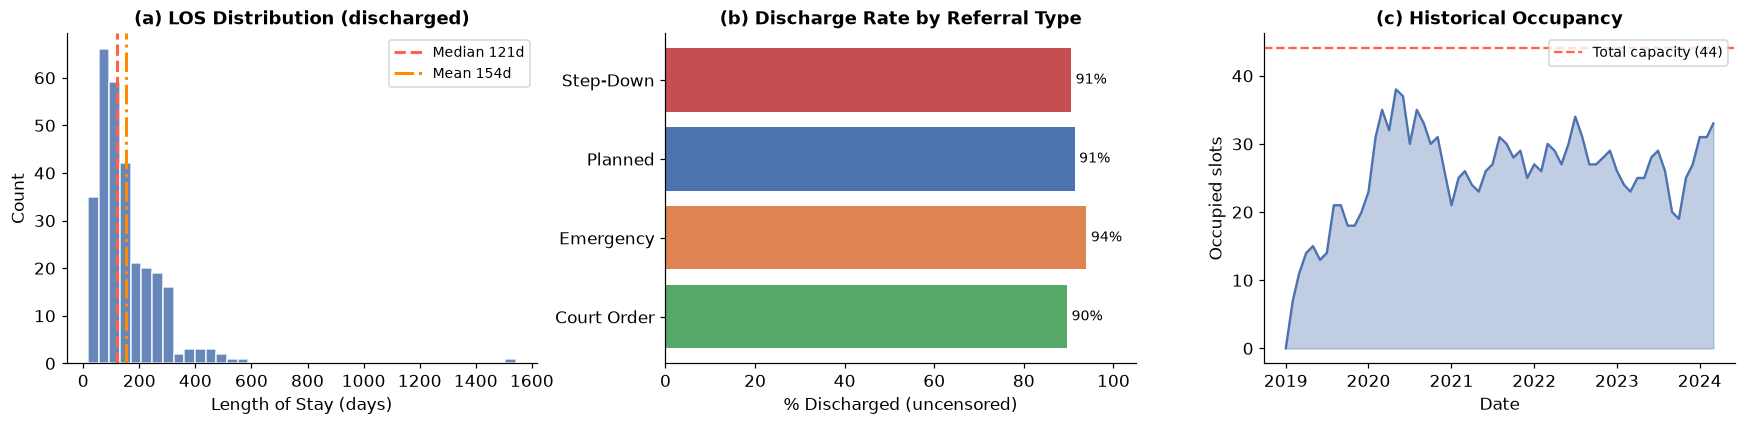

LOS summary (discharged only):
count     294.0
mean      154.1
std       128.2
min        17.0
25%        81.0
50%       121.0
75%       199.0
max      1542.0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) LOS histogram
ax = axes[0]
discharged = df[df["event"] == 1]["duration_days"]
ax.hist(discharged, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(discharged.median(), color="tomato", lw=2, ls="--",
           label=f"Median {discharged.median():.0f}d")
ax.axvline(discharged.mean(), color="darkorange", lw=2, ls="-.",
           label=f"Mean {discharged.mean():.0f}d")
ax.set_xlabel("Length of Stay (days)")
ax.set_ylabel("Count")
ax.set_title("(a) LOS Distribution (discharged)")
ax.legend(fontsize=9)

# (b) Discharge rate by referral type
ax = axes[1]
cens = (
    df.groupby("referral_type")["event"]
    .agg(discharged="sum", total="count")
    .assign(pct_discharged=lambda x: x["discharged"] / x["total"] * 100)
    .reset_index()
)
ref_colors = {"Emergency": "#dd8452", "Planned": "#4c72b0",
              "Court Order": "#55a868", "Step-Down": "#c44e52"}
bars = ax.barh(cens["referral_type"], cens["pct_discharged"],
               color=[ref_colors[r] for r in cens["referral_type"]])
ax.set_xlabel("% Discharged (uncensored)")
ax.set_title("(b) Discharge Rate by Referral Type")
ax.set_xlim(0, 105)
for bar, val in zip(bars, cens["pct_discharged"]):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va="center", fontsize=9)

# (c) Occupancy over time
ax = axes[2]
months = pd.date_range(SIMULATION_START, TODAY, freq="MS")
occ = []
for month in months:
    end_dates = df["admission_date"] + pd.to_timedelta(df["duration_days"], unit="D")
    n = int(((df["admission_date"] <= month) & (end_dates > month)).sum())
    occ.append(n)
ax.fill_between(months, occ, alpha=0.35, color="#4C72B0")
ax.plot(months, occ, color="#4C72B0", lw=1.5)
ax.axhline(TOTAL_CAPACITY, color="tomato", lw=1.5, ls="--",
           label=f"Total capacity ({TOTAL_CAPACITY})")
ax.set_xlabel("Date")
ax.set_ylabel("Occupied slots")
ax.set_title("(c) Historical Occupancy")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())

plt.tight_layout()
plt.show()

print("LOS summary (discharged only):")
print(discharged.describe().apply(lambda x: f"{x:.1f}").to_string())


## 3 · Kaplan–Meier Estimator

The **Kaplan–Meier (KM)** curve is the non-parametric estimate of the survival function S(t) = P(still placed after t days). No distributional assumptions are needed.

Key interpretation for resource planning:
* **S(t)** — expected fraction of placements still active at day t
* **1 − S(t)** — probability a placement has ended by day t
* **Median** — day by which 50% of placements have ended

We fit KM curves overall and stratified by referral type and age group to reveal heterogeneity relevant to individual slot forecasts.


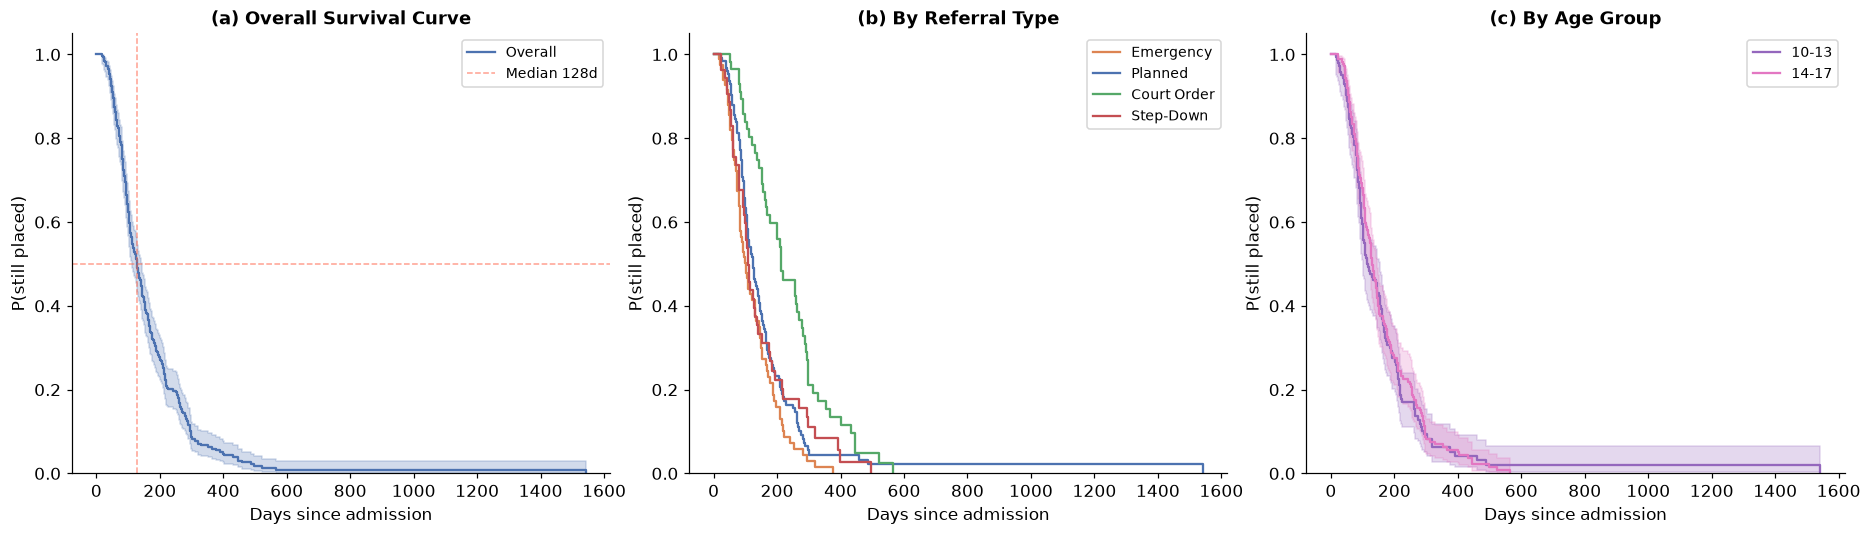

Median LOS (KM) — Overall :    128 days
  Emergency      :    101 days
  Planned        :    124 days
  Court Order    :    213 days
  Step-Down      :    107 days


In [4]:
kmf_overall = KaplanMeierFitter(label="Overall")
kmf_overall.fit(df["duration_days"], event_observed=df["event"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Overall KM
ax = axes[0]
kmf_overall.plot_survival_function(ax=ax, ci_show=True, color="#4C72B0")
ax.axhline(0.5, color="tomato", lw=1, ls="--", alpha=0.6)
ax.axvline(kmf_overall.median_survival_time_, color="tomato", lw=1, ls="--", alpha=0.6,
           label=f"Median {kmf_overall.median_survival_time_:.0f}d")
ax.set_xlabel("Days since admission")
ax.set_ylabel("P(still placed)")
ax.set_title("(a) Overall Survival Curve")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# (b) By referral type
ax = axes[1]
ref_colors = {"Emergency": "#dd8452", "Planned": "#4c72b0",
              "Court Order": "#55a868", "Step-Down": "#c44e52"}
kmf_ref = {}
for ref_type, color in ref_colors.items():
    mask = df["referral_type"] == ref_type
    kmf = KaplanMeierFitter(label=ref_type)
    kmf.fit(df.loc[mask, "duration_days"], event_observed=df.loc[mask, "event"])
    kmf.plot_survival_function(ax=ax, ci_show=False, color=color)
    kmf_ref[ref_type] = kmf
ax.set_xlabel("Days since admission")
ax.set_ylabel("P(still placed)")
ax.set_title("(b) By Referral Type")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# (c) By age group
ax = axes[2]
age_colors = {"10-13": "#9467bd", "14-17": "#e377c2"}
kmf_age = {}
for age_grp, color in age_colors.items():
    mask = df["age_group"] == age_grp
    kmf = KaplanMeierFitter(label=age_grp)
    kmf.fit(df.loc[mask, "duration_days"], event_observed=df.loc[mask, "event"])
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)
    kmf_age[age_grp] = kmf
ax.set_xlabel("Days since admission")
ax.set_ylabel("P(still placed)")
ax.set_title("(c) By Age Group")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Median LOS (KM) — Overall : {kmf_overall.median_survival_time_:>6.0f} days")
for ref_type, kmf in kmf_ref.items():
    print(f"  {ref_type:<14} : {kmf.median_survival_time_:>6.0f} days")


## 4 · Log-rank Tests — Are Subgroup Differences Significant?

Before building a covariate model we confirm that the stratified KM curves differ significantly using the **log-rank test** (H₀: identical survival distributions across groups).


In [5]:
result_ref = multivariate_logrank_test(
    df["duration_days"], df["referral_type"], event_observed=df["event"]
)
print("Log-rank test — Referral Type (4 groups)")
print(f"  chi2 = {result_ref.test_statistic:.2f},  p = {result_ref.p_value:.2e}")
sig_ref = "Significant (p < 0.05)" if result_ref.p_value < 0.05 else "Not significant (p >= 0.05)"
print(f"  --> {sig_ref}\n")

mask_1013 = df["age_group"] == "10-13"
mask_1417 = df["age_group"] == "14-17"
result_age = logrank_test(
    df.loc[mask_1013, "duration_days"], df.loc[mask_1417, "duration_days"],
    event_observed_A=df.loc[mask_1013, "event"],
    event_observed_B=df.loc[mask_1417, "event"],
)
print("Log-rank test — Age Group (10-13 vs 14-17)")
print(f"  chi2 = {result_age.test_statistic:.2f},  p = {result_age.p_value:.2e}")
sig_age = "Significant (p < 0.05)" if result_age.p_value < 0.05 else "Not significant"
print(f"  --> {sig_age}\n")

for a, b in [("Emergency", "Court Order"), ("Planned", "Court Order")]:
    ma = df["referral_type"] == a
    mb = df["referral_type"] == b
    lr = logrank_test(
        df.loc[ma, "duration_days"], df.loc[mb, "duration_days"],
        event_observed_A=df.loc[ma, "event"], event_observed_B=df.loc[mb, "event"],
    )
    sig = "significant" if lr.p_value < 0.05 else "not significant"
    print(f"Log-rank {a} vs {b}: p = {lr.p_value:.2e}  --> {sig}")


Log-rank test — Referral Type (4 groups)
  chi2 = 28.39,  p = 3.00e-06
  --> Significant (p < 0.05)

Log-rank test — Age Group (10-13 vs 14-17)
  chi2 = 0.17,  p = 6.77e-01
  --> Not significant

Log-rank Emergency vs Court Order: p = 6.01e-09  --> significant
Log-rank Planned vs Court Order: p = 1.08e-04  --> significant


## 5 · Cox Proportional Hazards — Risk Factors for Discharge

The **Cox model** estimates a hazard ratio (HR) for each covariate:

* **HR > 1** → higher discharge rate → shorter stays (frees slots sooner)
* **HR < 1** → lower discharge rate → longer stays (blocks slots longer)

Practically: HR for Court Order < 1 means court-ordered young people stay longer, so those slots should be planned as unavailable for longer when forecasting.


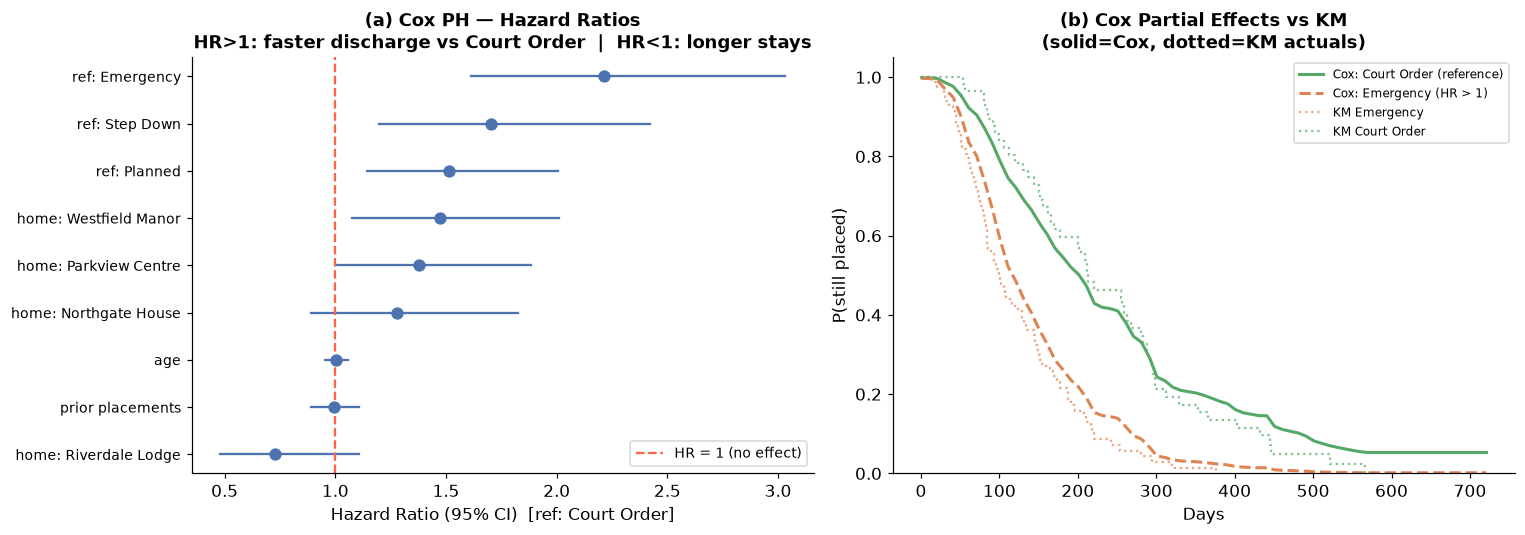

Cox concordance index: 0.640

Top 5 covariates by effect size (|log HR|):
covariate
referral_type_Emergency      0.794492
referral_type_Step_Down      0.531692
referral_type_Planned        0.414337
home_name_Westfield_Manor    0.386867
home_name_Parkview_Centre    0.319972


In [6]:
cox_df = pd.get_dummies(
    df[["duration_days", "event", "age", "prior_placements",
        "referral_type", "home_name"]],
    columns=["referral_type", "home_name"],
    drop_first=True,
)
# After drop_first=True, 'Court Order' (alphabetically first) is the reference baseline
# HR > 1 for Emergency/Planned/Step-Down means faster discharge vs Court Order
cox_df.columns = [c.replace(" ", "_").replace("-", "_") for c in cox_df.columns]

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col="duration_days", event_col="event", show_progress=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Forest plot
ax = axes[0]
hr  = cph.hazard_ratios_.sort_values()
ci  = cph.confidence_intervals_
covs = hr.index.tolist()
y    = range(len(covs))
ax.scatter(hr.values, list(y), color="#4C72B0", zorder=3, s=50)
for i, cov in enumerate(covs):
    lo = np.exp(ci.loc[cov, "95% lower-bound"])
    hi = np.exp(ci.loc[cov, "95% upper-bound"])
    ax.plot([lo, hi], [i, i], color="#4C72B0", lw=1.5)
ax.axvline(1.0, color="tomato", lw=1.5, ls="--", label="HR = 1 (no effect)")
ax.set_yticks(list(y))
ax.set_yticklabels(
    [c.replace("referral_type_", "ref: ").replace("home_name_", "home: ")
      .replace("_", " ") for c in covs], fontsize=9
)
ax.set_xlabel("Hazard Ratio (95% CI)  [ref: Court Order]")
ax.set_title("(a) Cox PH — Hazard Ratios\nHR>1: faster discharge vs Court Order  |  HR<1: longer stays")
ax.legend(fontsize=9)

# (b) Partial effects: Emergency vs Court Order (baseline), using predict_survival_function
ax = axes[1]
t_range = np.arange(1, 730, 10)
central = cph._central_values.copy()

for flag, label, color, ls in [(0, "Court Order (reference)", "#55a868", "-"),
                                (1, "Emergency (HR > 1)",      "#dd8452", "--")]:
    row = central.copy()
    row["referral_type_Emergency"]  = flag
    row["referral_type_Planned"]    = 0
    row["referral_type_Step_Down"]  = 0
    sf = cph.predict_survival_function(row, times=t_range)
    ax.plot(t_range, sf.values.flatten(), color=color, lw=2, ls=ls, label=f"Cox: {label}")

# Overlay KM for calibration
for ref_type, color, ls in [("Emergency", "#dd8452", ":"), ("Court Order", "#55a868", ":")]:
    mask = df["referral_type"] == ref_type
    kmf_tmp = KaplanMeierFitter(label=f"KM {ref_type}")
    kmf_tmp.fit(df.loc[mask, "duration_days"], event_observed=df.loc[mask, "event"])
    kmf_tmp.plot_survival_function(ax=ax, ci_show=False, color=color, ls=ls, alpha=0.7)

ax.set_xlabel("Days")
ax.set_ylabel("P(still placed)")
ax.set_title("(b) Cox Partial Effects vs KM\n(solid=Cox, dotted=KM actuals)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Cox concordance index: {cph.concordance_index_:.3f}")
print("\nTop 5 covariates by effect size (|log HR|):")
print(np.log(cph.hazard_ratios_).abs().sort_values(ascending=False).head(5).to_string())


## 6 · Weibull AFT — Parametric Survival Model

While Cox PH is excellent for understanding risk factors, it produces a *step-function* survival curve limited to the range of observed data. For **forward projection** beyond observed durations we need a **parametric model**.

The **Weibull Accelerated Failure Time (AFT)** model expresses:

> log(T) = X*beta + sigma*epsilon

where epsilon follows a Gumbel distribution, giving the Weibull distribution for T.  
The shape parameter rho > 1 means hazard *increases* over time (young people still placed after a long period become progressively more likely to leave).

We use this model's smooth survival function for the slot-availability projection.


<lifelines.WeibullAFTFitter: fitted with 321 total observations, 27 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
                penalizer = 0.01
   number of observations = 321
number of events observed = 294
           log-likelihood = -1756.881
         time fit was run = 2026-07-21 11:45:47 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                          
lambda_ age              -0.027     0.973     0.018          -0.063           0.009               0.939               1.009
        prior_placements -0.026     0.974     0.038          -0.102           0.049               0.903               1.050
        ref_court_order   0.331     1.392     0.116           0.103           0.559               1.108               1.748
        ref_emergency    -0.355     0.701     0.099          -0.549          -0.160               0.578               0.852
        ref_step_down    -0.124     0.884     0.117          -0.352           0.105               0.703               1.110
        Intercept         5.637   280.661     0.255           5.138           6.136             170.368             462.356
rho_    Intercept         0.394     1.483     0.040           0.315           0.472               1.370               1.604

                          cmp to      z       p  -log2(p)
param   covariate                                        
lambda_ age                0.000 -1.479   0.139     2.845
        prior_placements   0.000 -0.683   0.495     1.015
        ref_court_order    0.000  2.845   0.004     7.816
        ref_emergency      0.000 -3.577 <0.0005    11.491
        ref_step_down      0.000 -1.063   0.288     1.797
        Intercept          0.000 22.133 <0.0005   358.171
rho_    Intercept          0.000  9.816 <0.0005    73.147
---
Concordance = 0.594
AIC = 3527.762
log-likelihood ratio test = 31.169 on 5 df
-log2(p) of ll-ratio test = 16.815

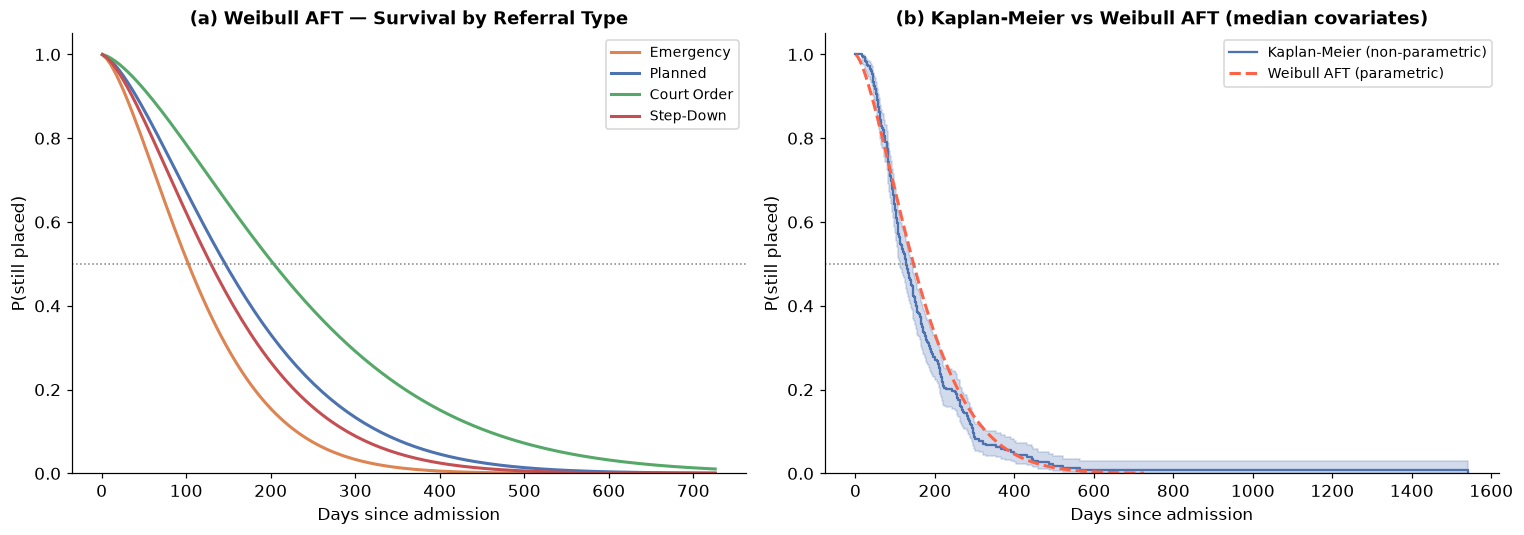

Weibull median LOS (median covariates): 146 days
KM median LOS overall:                  128 days


In [7]:
aft_df = df[["duration_days", "event", "age", "prior_placements"]].copy()
aft_df["ref_emergency"]   = (df["referral_type"] == "Emergency").astype(int)
aft_df["ref_court_order"] = (df["referral_type"] == "Court Order").astype(int)
aft_df["ref_step_down"]   = (df["referral_type"] == "Step-Down").astype(int)

waf = WeibullAFTFitter(penalizer=0.01)
waf.fit(aft_df, duration_col="duration_days", event_col="event", show_progress=False)
waf.print_summary(decimals=3)

# Survival curves by referral type at median covariates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
t_range = np.arange(1, 730, 5)
median_age  = float(df["age"].median())
median_prio = float(df["prior_placements"].median())
ref_scenarios = [
    ("Emergency",   "#dd8452", 1, 0, 0),
    ("Planned",     "#4c72b0", 0, 0, 0),
    ("Court Order", "#55a868", 0, 1, 0),
    ("Step-Down",   "#c44e52", 0, 0, 1),
]
for label, color, e, c, s in ref_scenarios:
    sample = pd.DataFrame([{
        "duration_days": 1, "event": 1,
        "age": median_age, "prior_placements": median_prio,
        "ref_emergency": e, "ref_court_order": c, "ref_step_down": s,
    }])
    sf = waf.predict_survival_function(sample, times=t_range)
    ax.plot(t_range, sf.values.flatten(), color=color, lw=2, label=label)
ax.axhline(0.5, color="grey", lw=1, ls=":")
ax.set_xlabel("Days since admission")
ax.set_ylabel("P(still placed)")
ax.set_title("(a) Weibull AFT — Survival by Referral Type")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

ax = axes[1]
kmf_overall.plot_survival_function(ax=ax, ci_show=True, color="#4C72B0",
                                    label="Kaplan-Meier (non-parametric)")
sample_avg = pd.DataFrame([{
    "duration_days": 1, "event": 1,
    "age": median_age, "prior_placements": median_prio,
    "ref_emergency": 0, "ref_court_order": 0, "ref_step_down": 0,
}])
sf_waf = waf.predict_survival_function(sample_avg, times=t_range)
ax.plot(t_range, sf_waf.values.flatten(), color="tomato", lw=2, ls="--",
        label="Weibull AFT (parametric)")
ax.axhline(0.5, color="grey", lw=1, ls=":")
ax.set_xlabel("Days since admission")
ax.set_ylabel("P(still placed)")
ax.set_title("(b) Kaplan-Meier vs Weibull AFT (median covariates)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

median_age  = float(df["age"].median())
median_prio = float(df["prior_placements"].median())
print(f"Weibull median LOS (median covariates): {waf.predict_median(sample_avg).values[0]:.0f} days")
print(f"KM median LOS overall:                  {kmf_overall.median_survival_time_:.0f} days")


## 7 · Available-Slot Forecast — 26 Weeks Ahead

### Method

For each **currently active placement** i (admitted d_i days ago), the probability it **still occupies a slot** at t days from now is the **conditional survival probability**:

```
P(still placed at t | still placed now) = S(d_i + t) / S(d_i)
```

where S(.) is the Weibull AFT survival function at that placement's covariate values.

**Expected occupancy at time t** (from existing placements):

```
E[occupied(t)] = sum_i  S(d_i + t) / S(d_i)
```

**Available slots** (vacancies opening as existing residents leave):

```
available_existing(t) = max(0, capacity - E[occupied(t)])
```

> **Note:** This is the lower bound on availability from existing placements. Section 8 combines this with the demand forecast to get net availability for new referrals.


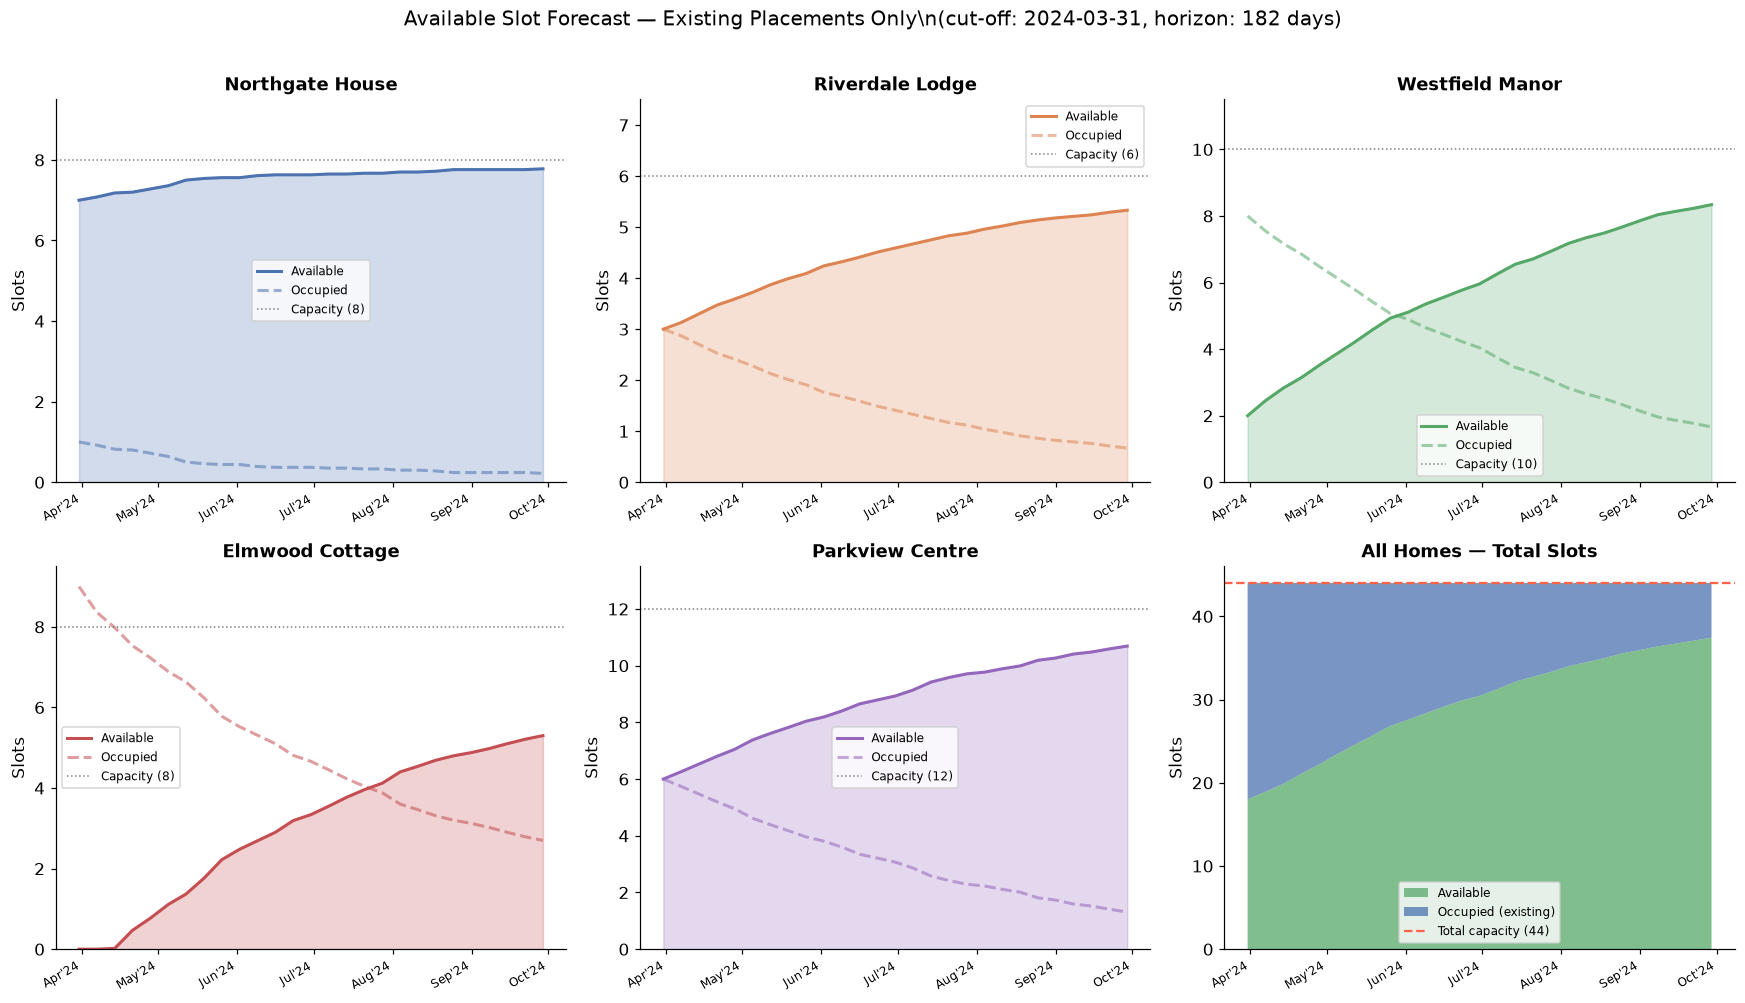

Available Slots Forecast (from existing placements clearing):
                 Today  +4wk  +8wk  +13wk  +26wk
home_name                                       
Northgate House    7.0   7.3   7.6    7.6    7.8
Riverdale Lodge    3.0   3.6   4.1    4.6    5.3
Westfield Manor    2.0   3.5   4.9    6.0    8.3
Elmwood Cottage    0.0   0.8   2.2    3.3    5.3
Parkview Centre    6.0   7.0   8.0    8.9   10.7

Horizon   Available   Capacity  Vacancy %
Today          18.0         44        41%
+4wk           22.2         44        50%
+8wk           26.8         44        61%
+13wk          30.4         44        69%
+26wk          37.4         44        85%


In [8]:
HORIZON_DAYS = 182       # 26 weeks
PROJ_DAYS    = list(range(0, HORIZON_DAYS + 1, 7))

# ─── Slot availability projection using KM conditional survival ────────────────
#
# For each active placement i (duration d_i days so far):
#   P(still placed at t days from now | still placed now) = S(d_i + t) / S(d_i)
# where S(.) comes from the Kaplan-Meier estimator.
#
# Weibull AFT gives per-covariate survival curves (Section 6); here we use KM
# for the projection to avoid per-individual function evaluations.

proj_rows_all = []

for home_name, cfg in HOMES.items():
    home_active = active_df[active_df["home_name"] == home_name]
    capacity    = cfg["capacity"]
    d_values    = home_active["current_duration"].values   # days already spent

    if len(home_active) == 0:
        for t in PROJ_DAYS:
            proj_rows_all.append({
                "home_name": home_name, "days_ahead": t,
                "capacity": capacity,
                "expected_occupancy_existing": 0.0,
                "available_slots": float(capacity),
                "projection_date": TODAY + timedelta(days=t),
            })
        continue

    # Pre-compute S(d_i) for each active placement (denominator)
    s_now = np.array(
        [float(kmf_overall.survival_function_at_times(d).iloc[0]) for d in d_values]
    )

    for t in PROJ_DAYS:
        # S(d_i + t) for each active placement
        s_future = np.array(
            [float(kmf_overall.survival_function_at_times(d + t).iloc[0]) for d in d_values]
        )
        # Conditional survival: P(still there at t | still there now)
        cond_p   = np.where(s_now > 1e-6, np.clip(s_future / s_now, 0, 1), 0.0)
        exp_occ  = float(cond_p.sum())
        available = max(0.0, capacity - exp_occ)
        proj_rows_all.append({
            "home_name": home_name, "days_ahead": t,
            "capacity": capacity,
            "expected_occupancy_existing": round(exp_occ, 2),
            "available_slots": round(available, 2),
            "projection_date": TODAY + timedelta(days=t),
        })

proj_df = pd.DataFrame(proj_rows_all)

# ─── Per-facility + total plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467BD"]

for idx, (home_name, cfg) in enumerate(HOMES.items()):
    ax    = axes[idx]
    hp    = proj_df[proj_df["home_name"] == home_name].sort_values("days_ahead")
    cap   = cfg["capacity"]
    color = COLORS[idx]
    ax.fill_between(hp["projection_date"], hp["available_slots"],
                    alpha=0.25, color=color)
    ax.plot(hp["projection_date"], hp["available_slots"],
            color=color, lw=2, label="Available")
    ax.plot(hp["projection_date"], hp["expected_occupancy_existing"],
            color=color, lw=2, ls="--", alpha=0.55, label="Occupied")
    ax.axhline(cap, color="grey", lw=1, ls=":", label=f"Capacity ({cap})")
    ax.set_title(home_name)
    ax.set_ylabel("Slots")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b'%y"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, cap + 1.5)
    ax.legend(fontsize=8)

# Summary: all homes stacked
ax = axes[5]
tot = (
    proj_df.groupby("days_ahead")
    .agg(available_slots=("available_slots", "sum"),
         total_capacity=("capacity", "sum"))
    .reset_index()
)
tot["projection_date"] = TODAY + pd.to_timedelta(tot["days_ahead"], unit="D")
tot["occupied"] = tot["total_capacity"] - tot["available_slots"]
ax.stackplot(
    tot["projection_date"],
    tot["available_slots"],
    tot["occupied"],
    labels=["Available", "Occupied (existing)"],
    colors=["#55A868", "#4C72B0"],
    alpha=0.75,
)
ax.axhline(TOTAL_CAPACITY, color="tomato", lw=1.5, ls="--",
           label=f"Total capacity ({TOTAL_CAPACITY})")
ax.set_title(f"All Homes — Total Slots")
ax.set_ylabel("Slots")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b'%y"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
ax.legend(fontsize=8)
ax.set_ylim(0, TOTAL_CAPACITY + 2)

plt.suptitle(
    f"Available Slot Forecast — Existing Placements Only\\n"
    f"(cut-off: {TODAY.date()}, horizon: {HORIZON_DAYS} days)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

# Summary table
milestone_days = [0, 28, 56, 91, 182]
summary_tab = (
    proj_df[proj_df["days_ahead"].isin(milestone_days)]
    .pivot_table(index="home_name", columns="days_ahead", values="available_slots")
    .reindex(list(HOMES.keys()))
)
summary_tab.columns = ["Today", "+4wk", "+8wk", "+13wk", "+26wk"]
print("Available Slots Forecast (from existing placements clearing):")
print(summary_tab.round(1).to_string())
print()
tot_miles = (
    proj_df[proj_df["days_ahead"].isin(milestone_days)]
    .groupby("days_ahead")["available_slots"].sum()
)
print(f"{'Horizon':<8} {'Available':>10} {'Capacity':>10} {'Vacancy %':>10}")
for t, lbl in zip(milestone_days, ["Today", "+4wk", "+8wk", "+13wk", "+26wk"]):
    av = tot_miles[t]
    print(f"{lbl:<8} {av:>10.1f} {TOTAL_CAPACITY:>10}  {av/TOTAL_CAPACITY:>9.0%}")


## 8 · Integrating with the OOH Demand Forecast

The slot-availability forecast above accounts for **existing placements clearing**. To get **net** availability for *new referrals*, we subtract the expected new placements coming from the demand model.

### Formula

```
net_available(t)  =  available_existing(t)
                   - E[occupancy from new admissions by time t]
```

Expected occupancy from new admissions arriving at rate lambda(s):

```
E[occ_new(t)] = integral_0^t  lambda(s) * S(t - s) ds
```

In practice `lambda(s)` comes from the `ooh_care_forecasts` Delta table (output of notebooks 01–07).


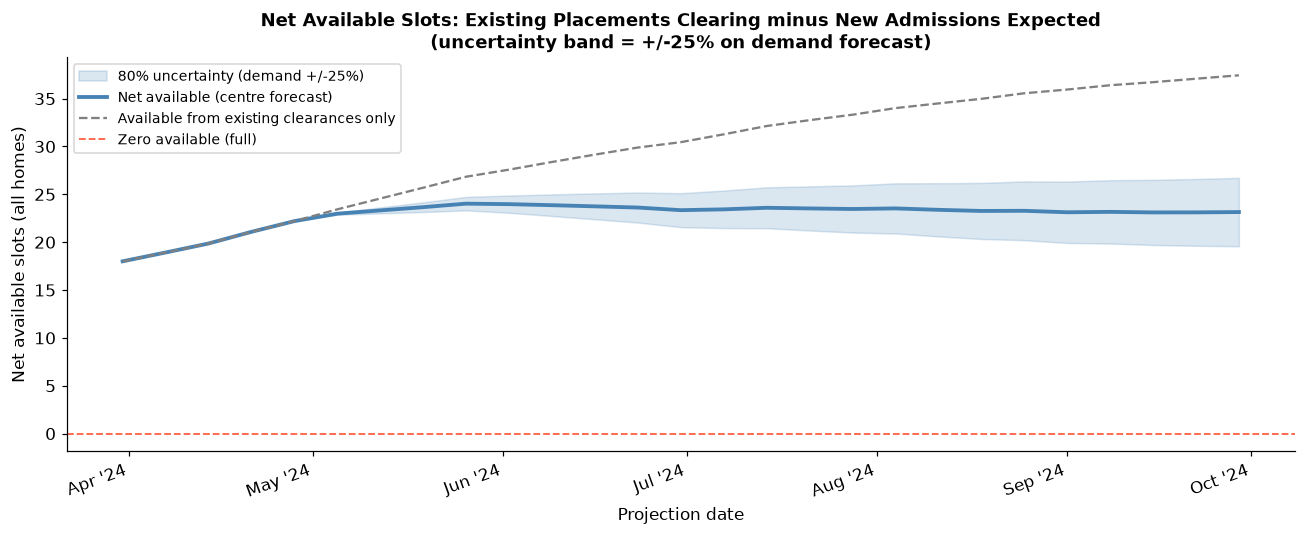

Horizon   Exist avail  Occ from new  Net avail
Today            18.0           0.0       18.0
+7d              18.9           0.0       18.9
+14d             19.9           0.0       19.9
+21d             21.1           0.0       21.1
+28d             22.2           0.0       22.2
+35d             23.4           0.5       23.0
+42d             24.6           1.2       23.3
+49d             25.7           2.0       23.7
+56d             26.8           2.8       24.0
+63d             27.6           3.6       24.0
+70d             28.4           4.5       23.9
+77d             29.1           5.4       23.7
+84d             29.9           6.3       23.6
+91d             30.4           7.1       23.3
+98d             31.3           7.8       23.4
+105d            32.1           8.5       23.6
+112d            32.8           9.2       23.5
+119d            33.3           9.9       23.5
+126d            34.0          10.5       23.5
+133d            34.5          11.1       23.4
+140d        

In [9]:
np.random.seed(SEED + 1)

# Hypothetical monthly demand forecast (new placements requested across all homes)
# In production: read from ooh_care_forecasts Delta table
demand_months      = pd.date_range(TODAY + pd.DateOffset(months=1),
                                   TODAY + pd.DateOffset(months=6), freq="MS")
monthly_new_admits = np.array([3.5, 4.0, 3.8, 4.2, 3.6, 3.9])   # point estimates

# Distribute to daily arrival rate
daily_lambda = {}
for month_ts, n in zip(demand_months, monthly_new_admits):
    n_days = pd.Period(month_ts, freq="M").days_in_month
    for d in range(n_days):
        daily_lambda[TODAY + timedelta(days=(month_ts - TODAY).days + d)] = n / n_days

# Numerical integration: E[occ from new admissions at t days from now]
def expected_occ_from_new(t_days, km_fitter, lam_dict):
    total = 0.0
    for s in range(t_days):
        day = TODAY + timedelta(days=s)
        lam = lam_dict.get(day, 0.0)
        if lam == 0:
            continue
        remaining = t_days - s
        s_val = float(km_fitter.survival_function_at_times(remaining).iloc[0])
        total += lam * s_val
    return total

t_array     = np.array(PROJ_DAYS)
occ_new     = [expected_occ_from_new(t, kmf_overall, daily_lambda) for t in t_array]
occ_new_lo  = [expected_occ_from_new(t, kmf_overall,
                {k: v * 0.75 for k, v in daily_lambda.items()}) for t in t_array]
occ_new_hi  = [expected_occ_from_new(t, kmf_overall,
                {k: v * 1.25 for k, v in daily_lambda.items()}) for t in t_array]

total_exist_map = dict(zip(
    proj_df.groupby("days_ahead")["available_slots"].sum().index,
    proj_df.groupby("days_ahead")["available_slots"].sum().values,
))
net      = [max(0, total_exist_map[t] - occ_new[i])    for i, t in enumerate(t_array)]
net_lo   = [max(0, total_exist_map[t] - occ_new_hi[i]) for i, t in enumerate(t_array)]
net_hi   = [max(0, total_exist_map[t] - occ_new_lo[i]) for i, t in enumerate(t_array)]
proj_dates = [TODAY + timedelta(days=int(t)) for t in t_array]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(proj_dates, net_lo, net_hi,
                alpha=0.2, color="steelblue", label="80% uncertainty (demand +/-25%)")
ax.plot(proj_dates, net,
        color="steelblue", lw=2.5, label="Net available (centre forecast)")
ax.plot(proj_dates, [total_exist_map[t] for t in t_array],
        color="grey", lw=1.5, ls="--", label="Available from existing clearances only")
ax.axhline(0, color="tomato", lw=1.2, ls="--", label="Zero available (full)")
ax.set_xlabel("Projection date")
ax.set_ylabel("Net available slots (all homes)")
ax.set_title(
    "Net Available Slots: Existing Placements Clearing minus New Admissions Expected\n"
    "(uncertainty band = +/-25% on demand forecast)"
)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(f"{'Horizon':<8} {'Exist avail':>12} {'Occ from new':>13} {'Net avail':>10}")
for i, (t, lbl) in enumerate(zip(t_array,
        ["Today  "] + [f"+{t}d  " for t in t_array[1:]])):
    ea = total_exist_map.get(t, 0)
    on = occ_new[i]
    na = max(0, ea - on)
    print(f"{lbl:<8} {ea:>12.1f} {on:>13.1f} {na:>10.1f}")


## 9 · Resource Planning Heatmap


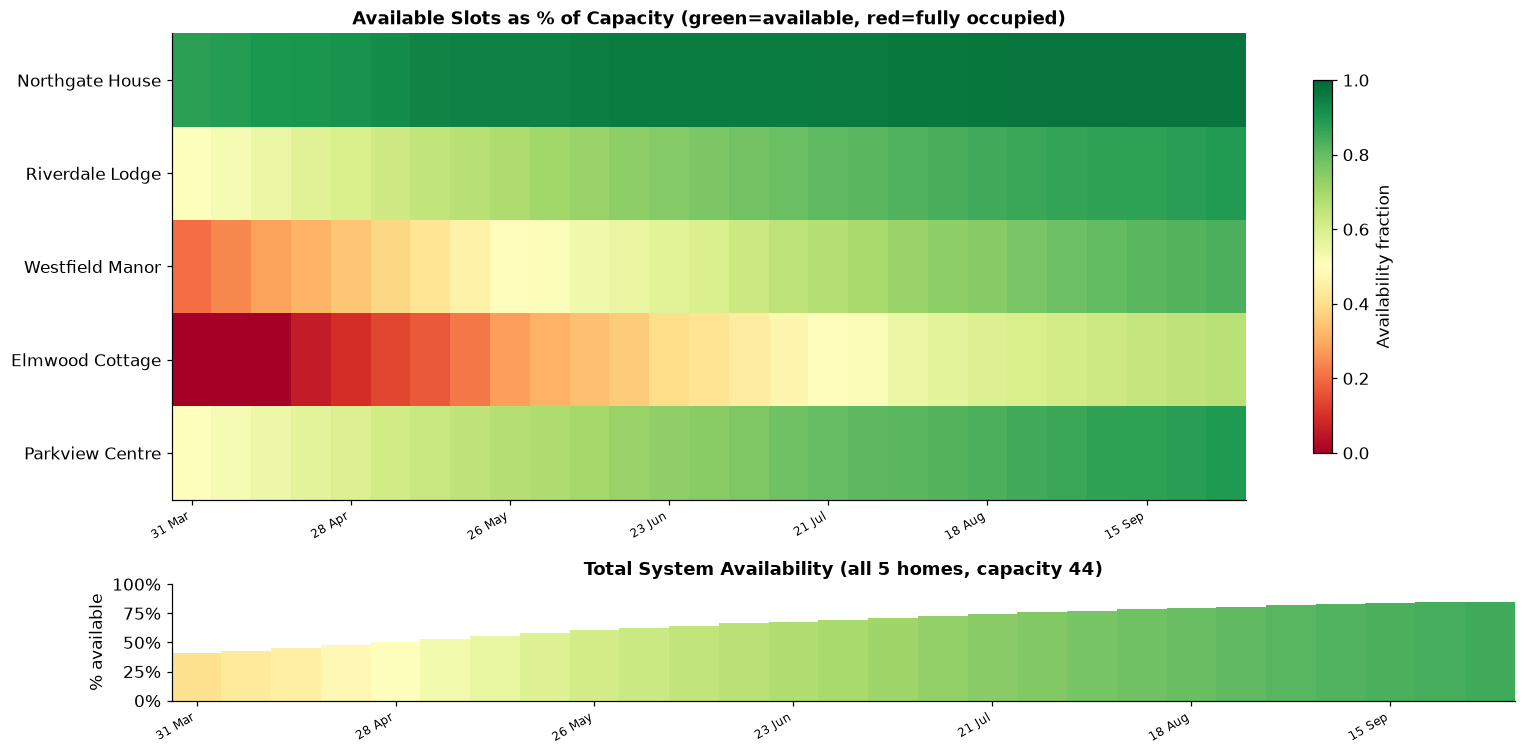

In [10]:
heatmap_data = proj_df.pivot_table(
    index="home_name", columns="projection_date", values="available_slots"
).reindex(list(HOMES.keys()))

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                          gridspec_kw={"height_ratios": [4, 1]})

ax = axes[0]
norm_data = heatmap_data.copy()
for home in heatmap_data.index:
    norm_data.loc[home] = heatmap_data.loc[home] / HOMES[home]["capacity"]

cmap = plt.cm.RdYlGn
im = ax.imshow(norm_data.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)
ax.set_yticks(range(len(norm_data.index)))
ax.set_yticklabels(norm_data.index)
col_dates = list(heatmap_data.columns)
tick_pos  = list(range(0, len(col_dates), 4))
ax.set_xticks(tick_pos)
ax.set_xticklabels([col_dates[i].strftime("%d %b") for i in tick_pos],
                   rotation=30, ha="right", fontsize=8)
ax.set_title("Available Slots as % of Capacity (green=available, red=fully occupied)")
plt.colorbar(im, ax=ax, label="Availability fraction", shrink=0.8)

ax2 = axes[1]
total_avail = heatmap_data.sum(axis=0)
total_pct   = total_avail / TOTAL_CAPACITY
ax2.bar(range(len(total_pct)), total_pct.values,
        color=[cmap(v) for v in total_pct.values], width=1)
ax2.set_ylim(0, 1)
ax2.set_xlim(-0.5, len(total_pct) - 0.5)
ax2.set_xticks(tick_pos)
ax2.set_xticklabels([col_dates[i].strftime("%d %b") for i in tick_pos],
                    rotation=30, ha="right", fontsize=8)
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax2.set_title(f"Total System Availability (all {len(HOMES)} homes, capacity {TOTAL_CAPACITY})")
ax2.set_ylabel("% available")

plt.tight_layout()
plt.show()


## 10 · Model Selection & Next Steps

### Which model to use in production?

| Use case | Recommended model |
|---|---|
| Quick portfolio-level vacancy estimate | Kaplan-Meier (no covariates needed) |
| Understanding discharge risk factors | Cox Proportional Hazards |
| Individual timelines / long-horizon extrapolation | Weibull AFT |
| Probabilistic planning with uncertainty bands | Weibull AFT + bootstrap or Bayesian |

### Validation checklist before production deployment

1. **Concordance index** — should be > 0.6  (`cph.concordance_index_`)
2. **PH assumption** — run `cph.check_assumptions(df, ...)` and inspect Schoenfeld residuals
3. **Calibration** — compare KM actual vs Weibull predicted at 30/60/90/180-day checkpoints
4. **Back-test** — refit on 2019-2022 data; evaluate slot forecast against 2023 actuals

### Extensions

* **Competing risks** — different discharge reasons (planned move, emergency, family return) → use `lifelines.AalenJohansenFitter` or Fine-Gray model from `scikit-survival`.
* **Time-varying covariates** — behaviour incidents, school changes affect risk over time → use `CoxTimeVaryingFitter`.
* **Operational integration** — write `(projection_date, home_name, available_slots)` to the `ooh_care_forecasts` Delta table so the `07_evaluation.py` dashboard can display supply and demand on a single chart.


In [11]:
print("=" * 58)
print("  SURVIVAL MODEL QUALITY SUMMARY")
print("=" * 58)
print(f"  Records in training set       : {len(df):>6,}")
print(f"  Event rate (discharged)       : {df['event'].mean():>6.1%}")
print(f"  KM median LOS                 : {kmf_overall.median_survival_time_:>6.0f} days")
print(f"  Cox concordance index         : {cph.concordance_index_:>6.3f}  (0.5=random, 1.0=perfect)")
print(f"  Weibull AIC                   : {waf.AIC_:>6.1f}")
median_age  = float(df['age'].median())
median_prio = float(df['prior_placements'].median())
sample_avg = pd.DataFrame([{
    'duration_days': 1, 'event': 1,
    'age': median_age, 'prior_placements': median_prio,
    'ref_emergency': 0, 'ref_court_order': 0, 'ref_step_down': 0,
}])
print(f"  Weibull median LOS (avg covs) : {waf.predict_median(sample_avg).values[0]:>6.0f} days")
print()
print("  Active placements today:")
for home, cfg in HOMES.items():
    n_act = len(active_df[active_df['home_name'] == home])
    row   = proj_df[(proj_df['home_name'] == home) & (proj_df['days_ahead'] == 0)]
    avail = row['available_slots'].values[0] if len(row) else cfg['capacity']
    print(f"    {home:<20} {n_act:>2}/{cfg['capacity']} occupied "
          f" -> {avail:.1f} available today")
print()
total_today = proj_df[proj_df['days_ahead'] == 0]['available_slots'].sum()
total_26wk  = proj_df[proj_df['days_ahead'] == 182]['available_slots'].sum()
print(f"  Total available today         : {total_today:>5.1f} / {TOTAL_CAPACITY}")
print(f"  Total available in 26 weeks   : {total_26wk:>5.1f} / {TOTAL_CAPACITY}"
      f"  (existing placements only)")
print("=" * 58)


  SURVIVAL MODEL QUALITY SUMMARY
  Records in training set       :    321
  Event rate (discharged)       :  91.6%
  KM median LOS                 :    128 days
  Cox concordance index         :  0.640  (0.5=random, 1.0=perfect)
  Weibull AIC                   : 3527.8
  Weibull median LOS (avg covs) :    146 days

  Active placements today:
    Northgate House       1/8 occupied  -> 7.0 available today
    Riverdale Lodge       3/6 occupied  -> 3.0 available today
    Westfield Manor       8/10 occupied  -> 2.0 available today
    Elmwood Cottage       9/8 occupied  -> 0.0 available today
    Parkview Centre       6/12 occupied  -> 6.0 available today

  Total available today         :  18.0 / 44
  Total available in 26 weeks   :  37.4 / 44  (existing placements only)
